<a href="https://colab.research.google.com/github/Sshahsavar/credit-risk-modeling/blob/main/Part_2_End_to_End_Credit_Risk_Modeling_(PD_%26_Portfolio_Optimization).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**End-to-End Credit Risk Modeling: Probability of Default (PD) & Portfolio Optimization (Lending Club Edition)**

Part 2 of the credit risk series. It requires the outputs of *Part 0: Credit Risk Data Foundation* (`lc_clean.pkl`) and *Part 3: LGD Modeling* (`lgd_satellite.json`).

---

* Project Overview & Data Source

Data Source: This project uses the Lending Club loan [dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club), prepared in Part 0. The modeling sample is the set of **36-month loans issued 2010–2015** with a known outcome (repaid or charged off). Each loan carries its real **interest rate, instalment, repayment timing and exposure at default**, so the profit analysis uses actual cash flows instead of assumptions.

Objective: To design a complete PD modeling framework that aligns with banking practice:
* an interpretable **WOE scorecard** (champion) and a **LightGBM** challenger;
* validation on an **out-of-time** vintage;
* checks of both **discrimination** (AUC, KS) and **calibration**;
* scaling of the model into **scorecard points**, with **SHAP** explanations;
* a **profit-optimal approval cut-off**, based on real interest income and the **LGD estimated in Part 3**.

---

* The Logic & Methodology

Target & Out-of-Time Design: Default = charged off within the 36-month life. The models train on the 2010–2014 vintages and are tested on 2015.

Domain Feature Engineering & WOE: Affordability ratios (loan-to-income, revolving-debt-to-income) are added to the borrower attributes. WOE bins and Information Value are computed **on the training set only**.

Champion vs. Challenger: A WOE logistic-regression scorecard is benchmarked against LightGBM. **No class weights are used.** Weighting leaves AUC unchanged but inflates the predicted PDs (by about 11× in the Home Credit version of this project), and calibrated PDs are needed for profit decisions.

Risk Evaluation: AUC and Gini, the Kolmogorov–Smirnov statistic, calibration by decile, and the Brier score. The scorecard is then converted into points with the industry-standard **PDO scaling**.

Explainability: SHAP values explain the LightGBM challenger.

Business Threshold Optimization: Every loan in the 2015 test vintage is valued with its **realized cash flows**:
* repaid loans earn the interest actually paid until payoff;
* defaulted loans earn interest until the last payment and then lose EAD × LGD.

The approval cut-off is searched over a wide grid, the optimum is checked against the analytical **break-even PD**, and the result is compared with the "approve everyone" policy Lending Club actually followed.

---

* Results & Business Impact

Rank-Ordering: On the 2015 out-of-time vintage (283,026 loans), the LightGBM challenger achieved **AUC 0.672 / KS 25.0**, against **AUC 0.649 / KS 21.3** for the 9-variable WOE scorecard. All scorecard coefficients have the correct sign, and default rates fall monotonically across score bands, from **29.4%** below 520 points to **2.6%** at 580–600.

Calibration: Both models **under-predict the 2015 default rate** (13.1% and 13.5% vs. **14.9%** actual), consistently across all deciles. This is a population shift toward riskier borrowers, and the fix is a recalibration of the intercept, not a new model.

Explainability: SHAP confirms intuitive drivers: FICO, income, recent credit inquiries, loan-to-income and DTI.

Portfolio Profitability: Using real interest income and the 91% LGD from Part 3, the break-even PD is **26.8%**. Lending Club's own risk-based pricing already made almost every approved loan profitable: approving everyone earned **$228.1M** on the 2015 vintage. The optimal LightGBM cut-off (PD ≤ 33%) declines only **1% of loans** and adds **$1.5M (+0.7%)**, while the scorecard adds virtually nothing. **The value of a PD model here lies in pricing and in screening new applicants, not in re-screening loans the lender had already approved.**

---

Tech Stack: Python, Pandas, Scikit-Learn, LightGBM, Scorecardpy, SHAP, SciPy, Matplotlib, Google Colab.

# Step 1: Environment Setup & Data Loading
We mount Google Drive and load the clean loan table from Part 0 and the LGD estimates from Part 3.

In [ ]:
try:
    import scorecardpy as sc
except ImportError:
    !pip install scorecardpy
    import scorecardpy as sc
try:
    import shap
except ImportError:
    !pip install shap
    import shap
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss
from IPython.display import display
warnings.filterwarnings('ignore')

# 1.1. Mount Google Drive and define the project folder
from google.colab import drive
drive.mount('/content/drive')
import google.colab.userdata
PROJECT_DIR = google.colab.userdata.get('credit_ris_DIR')

# 1.2. Load the Part 0 and Part 3 outputs
lc = pd.read_pickle(os.path.join(PROJECT_DIR, 'lc_clean.pkl'))
with open(os.path.join(PROJECT_DIR, 'lgd_satellite.json')) as f:
    lgd_sat = json.load(f)
print(f"Loans loaded: {len(lc):,}")
print(f"Long-run average LGD from Part 3: {lgd_sat['lra_default_weighted']:.2%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60724 sha256=97a434e0c942123491925fc8a56ac5917f16f0fbf007df20aaa1dbf1324d3dcb
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy


/usr/local/lib/python3.13/dist-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Mounted at /content/drive
Loans loaded: 2,260,668
Long-run average LGD from Part 3: 91.19%


# Step 2: Target Definition & Domain Feature Engineering
**Target.** A PD model must be trained on loans whose outcome is known. We keep **36-month loans issued 2010–2015**, which had all matured before the March 2019 snapshot. Default is defined as `TARGET = 1` when the loan was charged off, and 0 when it was fully repaid. Loans issued before 2010 are excluded, because Lending Club was very small then and applied a different credit policy.

**Features.** Only information available at the application date is used. Lending Club's `grade`, `sub_grade` and `int_rate` are excluded: they are the lender's own risk assessment, and including them would make our model a copy of Lending Club's model. Two domain ratios measure affordability:
* **Loan-to-Income** = loan amount ÷ annual income: how large is the loan relative to earnings?
* **Revolving-Debt-to-Income** = revolving balance ÷ annual income: how heavy is the existing card debt?

**Protected attributes.** Lending Club does not provide age or gender, unlike Home Credit, where `DAYS_BIRTH` (age) was used in the original version of this project. The borrower's state is excluded, because geography can act as a proxy for protected characteristics.

**Split.** Out-of-time: 2010–2014 for training, and the 2015 vintage for testing.

In [ ]:
print("--- Building the Modeling Sample ---")

# 1. 36-month loans issued 2010-2015 with a completed outcome
df = lc[(lc['term_m'] == 36) & lc['issue_year'].between(2010, 2015) & lc['outcome'].isin(['default', 'paid'])].copy()
df['TARGET'] = (df['outcome'] == 'default').astype(int)

# 2. Domain-specific affordability ratios
income = df['annual_inc'].where(df['annual_inc'] > 0)
df['log_annual_inc'] = np.log1p(df['annual_inc'].clip(lower=0))
df['LOAN_TO_INCOME'] = df['loan_amnt'] / income             # How large is the loan relative to earnings?
df['REVOL_DEBT_TO_INCOME'] = df['revol_bal'] / income       # How heavy is the existing revolving debt?

FEATURES = ['fico', 'dti', 'log_annual_inc', 'LOAN_TO_INCOME', 'REVOL_DEBT_TO_INCOME', 'revol_util', 'loan_amnt',
            'emp_years', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'mort_acc',
            'home_ownership', 'verification_status', 'purpose']

# 3. Out-of-time split
train = df[df['issue_year'] <= 2014].reset_index(drop=True)
test = df[df['issue_year'] == 2015].reset_index(drop=True)
y_train, y_test = train['TARGET'].values, test['TARGET'].values
print(f"Train (2010-2014): {len(train):,} loans | default rate {y_train.mean():.2%}")
print(f"Test  (2015):      {len(test):,} loans | default rate {y_test.mean():.2%}")

# 4. WOE binning and Information Value (fitted on the training set only)
print("\nCalculating Information Value (IV) and WOE bins on the training set...")
bins = sc.woebin(train[FEATURES + ['TARGET']], y='TARGET')
iv_df = pd.DataFrame({'Information Value (IV)': {k: v['total_iv'].iloc[0] for k, v in bins.items()}})
iv_df = iv_df.sort_values('Information Value (IV)', ascending=False)

print("\n--- Feature Information Value (IV) ---")
print("Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)")
display(iv_df.round(4))

strongest_feature = iv_df.index[0]
print(f"\n--- WOE Binning Details for: {strongest_feature} ---")
display(bins[strongest_feature][['bin', 'count_distr', 'badprob', 'woe', 'total_iv']])

# 5. Keep features with at least weak predictive power (IV >= 0.02) for the scorecard
SCORECARD_FEATURES = iv_df[iv_df['Information Value (IV)'] >= 0.02].index.tolist()
print(f"\nScorecard features (IV >= 0.02): {SCORECARD_FEATURES}")

--- Building the Modeling Sample ---
Train (2010-2014): 329,719 loans | default rate 13.07%
Test  (2015):      283,026 loans | default rate 14.89%

Calculating Information Value (IV) and WOE bins on the training set...
[INFO] creating woe binning ...
Binning on 329719 rows and 18 columns in 00:00:58

--- Feature Information Value (IV) ---
Rule of Thumb: < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)


,Information Value (IV)
fico,0.1373
log_annual_inc,0.0821
dti,0.0461
mort_acc,0.0435
LOAN_TO_INCOME,0.0417
home_ownership,0.0371
inq_last_6mths,0.0300
revol_util,0.0248
purpose,0.0217
emp_years,0.0174



--- WOE Binning Details for: fico ---


,bin,count_distr,badprob,woe,total_iv
0,"[-inf,685.0)",0.413197,0.169063,0.302483,0.137265
1,"[685.0,710.0)",0.305117,0.128137,-0.022765,0.137265
2,"[710.0,740.0)",0.177117,0.090293,-0.415303,0.137265
3,"[740.0,760.0)",0.050219,0.065104,-0.769677,0.137265
4,"[760.0,inf)",0.054349,0.045759,-1.142765,0.137265



Scorecard features (IV >= 0.02): ['fico', 'log_annual_inc', 'dti', 'mort_acc', 'LOAN_TO_INCOME', 'home_ownership', 'inq_last_6mths', 'revol_util', 'purpose']


## Conclusion:
1. **Sample.** There are **329,719 training loans** (default rate 13.07%) and **283,026 test loans** (14.89%). The riskier 2015 vintage creates exactly the population shift an out-of-time test is designed to expose.

2. **Predictive hierarchy.** **FICO** is the only medium-strength predictor (IV = 0.137). It is followed by income (0.082), DTI (0.046), number of mortgages (0.044), loan-to-income (0.042), home ownership (0.037), recent inquiries (0.030), revolving utilization (0.025) and purpose (0.022). These **9 features (IV ≥ 0.02)** enter the scorecard. Eight features with IV < 0.02 are dropped, among them employment length, loan amount, verification status and the revolving-debt-to-income ratio.

3. **Monotonic risk.** The FICO WOE table shows a clean, monotonic pattern. The default rate falls from **16.9%** below 685 to 12.8% (685–710), 9.0% (710–740), 6.5% (740–760) and **4.6%** at 760 and above. This is exactly the shape regulators expect from a scorecard variable. Note that 72% of the borrowers sit in the two lowest FICO bins, a reminder that Lending Club served mainly near-prime customers.

# Step 3: Champion vs. Challenger Models
We benchmark two models:

1. **The Champion: WOE Logistic Regression scorecard.** It is trained on the WOE values of the features with IV ≥ 0.02. This is the traditional, highly interpretable banking scorecard.

2. **The Challenger: LightGBM.** It is trained on raw features (categories as one-hot columns) and captures non-linear effects and interactions.

**Why no class weights?** The original version of this project used `scale_pos_weight` = 11.4 to handle the 11:1 imbalance. Weighting multiplies the odds of default by roughly the weight, so a LightGBM score of 0.50 corresponded to a true PD of only about 8%. AUC and KS are unaffected, but every probability-based decision (cut-offs, pricing, expected loss) becomes wrong. Both models are therefore trained **unweighted**, and their PDs stay on the true probability scale.

The **Kolmogorov–Smirnov** statistic measures the maximum distance between the score distributions of defaulters and non-defaulters:
$$KS = \max_s \big\lvert F_{\text{bad}}(s) - F_{\text{good}}(s) \big\rvert$$

In [ ]:
print("--- Training Champion & Challenger ---")

# 1. Champion: WOE logistic regression scorecard
def apply_woe(frame, bins_dict, label):
    """Apply WOE bins. Values never seen in training (e.g. a new category in 2015, or a missing value
    in a feature that had none in training) have no bin and come back as NaN. They receive WOE = 0,
    i.e. the average risk of the training population -- the neutral, standard treatment."""
    X = sc.woebin_ply(frame[list(bins_dict) + ['TARGET']], bins_dict).drop(columns='TARGET')
    unmatched = X.isna().sum()
    if unmatched.sum() > 0:
        print(f"{label}: values without a training bin -> WOE set to 0: {unmatched[unmatched > 0].to_dict()}")
    return X.fillna(0.0)

scorecard_bins = {k: bins[k] for k in SCORECARD_FEATURES}
X_train_woe = apply_woe(train, scorecard_bins, 'Train')
X_test_woe = apply_woe(test, scorecard_bins, 'Test (2015)')
lr = LogisticRegression(C=0.1, max_iter=1000)
lr.fit(X_train_woe, y_train)
lr_preds = lr.predict_proba(X_test_woe)[:, 1]

# 2. Challenger: LightGBM on raw features
def one_hot(frame, reference_columns=None):
    X = pd.get_dummies(frame[FEATURES], columns=['home_ownership', 'verification_status', 'purpose'], dtype=float)
    X.columns = [c.replace(' ', '_') for c in X.columns]
    return X if reference_columns is None else X.reindex(columns=reference_columns, fill_value=0.0)
X_train_lgb = one_hot(train)
X_test_lgb = one_hot(test, X_train_lgb.columns)
lgb_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31, min_child_samples=200,
                               subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)
lgb_model.fit(X_train_lgb, y_train)
lgb_preds = lgb_model.predict_proba(X_test_lgb)[:, 1]

# 3. Discrimination metrics
def ks_stat(y, p):
    return ks_2samp(p[y == 1], p[y == 0]).statistic * 100

metrics = pd.DataFrame({
    name: {'ROC-AUC': roc_auc_score(y_test, p), 'Gini': 2 * roc_auc_score(y_test, p) - 1, 'KS': ks_stat(y_test, p)}
    for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items()}).T
print("\n--- Model Benchmark Results (Out-of-Time: 2015 Vintage) ---")
display(metrics.round(4))

# 4. Scorecard coefficients (all should be positive: higher WOE = riskier bin)
print("\n--- Scorecard Coefficients ---")
display(pd.Series(lr.coef_[0], index=X_train_woe.columns, name='Coefficient').sort_values(ascending=False).round(4))

--- Training Champion & Challenger ---
[INFO] converting into woe values ...
Woe transformating on 329719 rows and 9 columns in 00:00:24
[INFO] converting into woe values ...
Woe transformating on 283026 rows and 9 columns in 00:00:10
Test (2015): values without a training bin -> WOE set to 0: {'LOAN_TO_INCOME_woe': 2, 'dti_woe': 2}

--- Model Benchmark Results (Out-of-Time: 2015 Vintage) ---


,ROC-AUC,Gini,KS
Champion: WOE Scorecard,0.6488,0.2976,21.3445
Challenger: LightGBM,0.6719,0.3437,25.0043



--- Scorecard Coefficients ---


,Coefficient
inq_last_6mths_woe,1.0952
purpose_woe,0.9184
fico_woe,0.8270
LOAN_TO_INCOME_woe,0.7202
dti_woe,0.5744
log_annual_inc_woe,0.5296
home_ownership_woe,0.4010
mort_acc_woe,0.2829
revol_util_woe,0.1831


## Conclusion:
1. **Discrimination.** LightGBM reaches **AUC 0.672 (Gini 0.344, KS 25.0)**, against **AUC 0.649 (Gini 0.298, KS 21.3)** for the WOE scorecard. The lift of **0.023 AUC** is well above the 0.01 rule of thumb, so the challenger adds real ranking power. Neither model reaches the KS > 30 often quoted for application scorecards. Among borrowers Lending Club had already approved, the remaining risk differences are subtle (see Part 1: even Lending Club's own sub-grade reaches only KS 26).

2. **The scorecard is clean.** All 9 coefficients are **positive**, as required by the WOE convention. There is no sign reversal and hence no evidence of harmful multicollinearity.
   * **Strongest weights:** recent inquiries (1.10), purpose (0.92), FICO (0.83) and loan-to-income (0.72).
   * **Inquiries, a credit-hungry signal:** borrowers who applied for credit several times in the last 6 months are riskier than their FICO alone suggests.

3. **Only 4 test values** needed the neutral WOE of 0 (2 in loan-to-income, 2 in DTI), which is immaterial.

# Step 4: Calibration & Scorecard Scaling
AUC and KS measure **ranking** only. Pricing, provisioning and cut-off decisions also need the **level** of the PD to be right. We check calibration in three ways:
* **Calibration-in-the-large:** mean predicted PD vs. actual default rate.
* **Calibration by decile:** mean predicted PD vs. actual default rate in each tenth of the population.
* **Brier score:** $\frac{1}{N}\sum_i (y_i - \hat p_i)^2$.

**Scorecard points.** Banks present a PD model as a **credit score**. With the standard **Points-to-Double-the-Odds (PDO)** scaling, a score of 600 corresponds to good:bad odds of 50:1, and every 20 points doubles the odds:
$$\text{Score} = \text{Offset} + \text{Factor}\cdot \ln\!\left(\frac{1-p}{p}\right), \qquad \text{Factor} = \frac{PDO}{\ln 2}, \qquad \text{Offset} = 600 - \text{Factor}\cdot\ln(50)$$

--- Calibration Check ---


,Mean Predicted PD,Actual Default Rate,Predicted / Actual,Brier Score
Champion: WOE Scorecard,0.1308,0.1489,0.8786,0.1227
Challenger: LightGBM,0.1350,0.1489,0.9070,0.1210



--- Default Rate by Credit Score Band (Champion Scorecard) ---


,Loans,Default_Rate,Share of Loans
SCORE_BAND,,,
"(-inf, 520.0]",14699,0.2941,0.0519
"(520.0, 540.0]",99089,0.2036,0.3501
"(540.0, 560.0]",119323,0.1240,0.4216
"(560.0, 580.0]",41411,0.0631,0.1463
"(580.0, 600.0]",8429,0.0255,0.0298
"(600.0, 620.0]",75,0.0267,0.0003


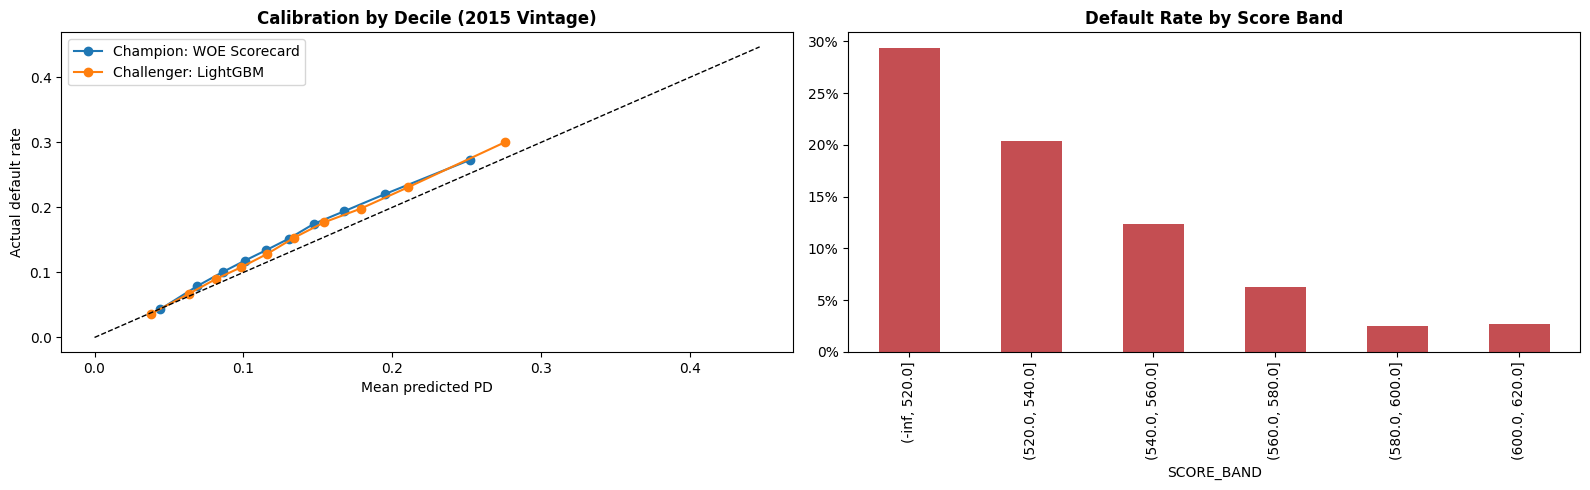

In [ ]:
print("--- Calibration Check ---")

# 1. Calibration-in-the-large and Brier score
calib = pd.DataFrame({
    name: {'Mean Predicted PD': p.mean(), 'Actual Default Rate': y_test.mean(),
           'Predicted / Actual': p.mean() / y_test.mean(), 'Brier Score': brier_score_loss(y_test, p)}
    for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items()}).T
display(calib.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 2. Calibration by decile
for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items():
    decile = pd.qcut(pd.Series(p).rank(method='first'), 10, labels=False)
    cal = pd.DataFrame({'pred': p, 'actual': y_test, 'decile': decile}).groupby('decile').mean()
    axes[0].plot(cal['pred'], cal['actual'], marker='o', label=name)
top = max(y_test.mean() * 3, 0.4)
axes[0].plot([0, top], [0, top], 'k--', lw=1)
axes[0].set_xlabel('Mean predicted PD'); axes[0].set_ylabel('Actual default rate')
axes[0].set_title('Calibration by Decile (2015 Vintage)', fontweight='bold'); axes[0].legend()

# 3. Scorecard scaling (PDO = 20, 600 points = 50:1 odds)
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
test['SCORE'] = offset + factor * np.log((1 - lr_preds) / lr_preds)
test['SCORE_BAND'] = pd.cut(test['SCORE'], bins=[-np.inf, 520, 540, 560, 580, 600, 620, np.inf])
bands = test.groupby('SCORE_BAND', observed=True).agg(Loans=('TARGET', 'size'), Default_Rate=('TARGET', 'mean'))
bands['Share of Loans'] = bands['Loans'] / len(test)
print("\n--- Default Rate by Credit Score Band (Champion Scorecard) ---")
display(bands.round(4))
bands['Default_Rate'].plot.bar(ax=axes[1], color='#C44E52')
axes[1].set_title('Default Rate by Score Band', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout(); plt.show()

## Conclusion:
1. **Calibration-in-the-large.** The scorecard predicts a mean PD of **13.1%** and LightGBM **13.5%**, against an actual 2015 default rate of **14.9%**. The predicted/actual ratios are 0.88 and 0.91. Both models under-predict by roughly 10%.

2. **The bias is a level shift, not a shape problem.** In the decile chart, both models run parallel to the 45° line, slightly above it, in every decile. The *ranking* is right, but the whole 2015 population is riskier than 2010–2014. A bank would apply an **intercept (calibration-in-the-large) adjustment** to the latest observed default rate rather than rebuild the model. The Brier scores favor LightGBM slightly (0.1210 vs. 0.1227).

3. **Score bands work as intended.** The default rate falls monotonically with the credit score:

| Score Band | Share of Loans | Default Rate |
|---|---|---|
| ≤ 520 | 5.2% | 29.4% |
| 520–540 | 35.0% | 20.4% |
| 540–560 | 42.2% | 12.4% |
| 560–580 | 14.6% | 6.3% |
| 580–600 | 3.0% | 2.6% |
| 600–620 | 0.03% | 2.7% (75 loans) |

   The riskiest band defaults **11 times** more often than the best populated band. The top band is too small to read. Most borrowers score between 520 and 560 points, which corresponds to PDs of about 10–20%. That is consistent with Lending Club's near-prime customer base.

# Step 5: Model Explainability (SHAP)
Under model-risk frameworks such as SR 11-7 (US) and OSFI Guideline E-23 (Canada), a bank must understand and explain how its models reach decisions. **SHAP** (SHapley Additive exPlanations) attributes each prediction of the LightGBM challenger to its features. Each feature receives its average marginal contribution across all possible orderings of the features:
$$\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!}\Big[f(S \cup \{j\}) - f(S)\Big]$$

The mean absolute SHAP value gives a global importance ranking, which can be compared with the IV ranking of the scorecard.

--- Generating SHAP Explanations (this may take a moment) ---

Top 10 Drivers of Default Risk (Global Interpretability):


,Feature,Mean Absolute SHAP
0,fico,0.305835
1,log_annual_inc,0.171761
2,inq_last_6mths,0.129228
3,LOAN_TO_INCOME,0.128955
4,dti,0.128109
5,open_acc,0.094169
6,REVOL_DEBT_TO_INCOME,0.093498
7,purpose_credit_card,0.076402
8,revol_util,0.065504
9,total_acc,0.058056


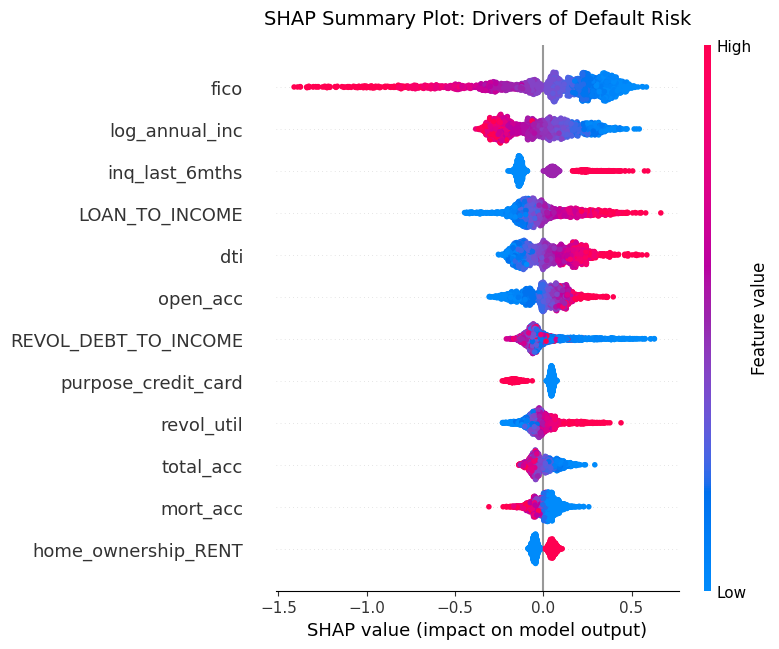

In [ ]:
print("--- Generating SHAP Explanations (this may take a moment) ---")
explainer = shap.TreeExplainer(lgb_model)
X_test_sample = X_test_lgb.sample(min(2000, len(X_test_lgb)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)
shap_vals_to_use = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_df = pd.DataFrame({'Feature': X_test_sample.columns,
                        'Mean Absolute SHAP': np.abs(shap_vals_to_use).mean(axis=0)}).sort_values('Mean Absolute SHAP', ascending=False)
print("\nTop 10 Drivers of Default Risk (Global Interpretability):")
display(shap_df.head(10).reset_index(drop=True))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_use, X_test_sample, show=False, max_display=12)
plt.title("SHAP Summary Plot: Drivers of Default Risk", fontsize=14, pad=15)
plt.show()

## Conclusion:
1. **Consistent drivers.** The SHAP ranking of LightGBM (FICO, income, recent inquiries, loan-to-income, DTI) matches the top of the IV ranking from Step 2. LightGBM's lift therefore comes from *better use of the same information*, through finer cut-points and interactions, and not from a hidden driver.

2. **Directions make economic sense.**
   * **Risk-reducing:** high FICO, high income, many mortgage accounts, and `purpose = credit_card` (refinancing card debt at a lower rate).
   * **Risk-increasing:** many recent inquiries, a high loan-to-income ratio, high DTI, high revolving utilization, and renting.

3. **One counter-intuitive pattern.** *Low* revolving-debt-to-income values push risk **up**. Borrowers with almost no revolving debt are often "thin-file" customers with little credit history, a known risk segment. This non-linear U-shape is exactly what a WOE scorecard with monotonic bins would miss. It is a candidate for a special bin in the next version of the scorecard.

# Step 6: Business Threshold Optimization & Financial Impact
ROC-AUC and KS do not pay the bills. The purpose of a PD model is to decide **which applicants to approve**. In the Home Credit version, every loan was assumed to be $15,000 at 12% interest, with a 60% LGD. Here, every 2015 test loan is valued with its **own realized economics**:

* **Repaid loan:** earns the interest actually paid until payoff. With monthly rate $r$, instalment $A$, amount $L$ and $k$ months of payments, the balance after $k$ payments is $B_k = L(1+r)^k - A\frac{(1+r)^k-1}{r}$. The interest earned is $k\cdot A - (L - B_k)$. A prepaid loan earns less interest than one that runs to maturity.
* **Defaulted loan:** earns interest until its last payment, then loses $EAD \times LGD$. EAD is the actual principal outstanding, and LGD is the grade-level long-run average from Part 3, about 91%.
* **Rejected loan:** zero profit.

**Decision rule.** Approve if the predicted PD ≤ cut-off. The cut-off is searched on a **wide grid (1%–80%)**, so that the optimum is not an artifact of where the grid stops, a weakness of the original version of this project.

**Analytical check.** A loan is worth approving when its expected profit is positive: $(1-p)\,G - p\,C > 0$. This gives the **break-even PD**
$$p^* = \frac{G}{G + C}$$
where $G$ is the average profit of a good loan and $C$ the average net cost of a defaulted loan. If the PDs are calibrated, the profit-maximizing cut-off should lie close to $p^*$.

--- Simulating Portfolio Financial Impact (2015 Vintage, Realized Cash Flows) ---
Average profit per good loan:        $1,811
Average net loss per defaulted loan: $4,942
Break-even PD  p* = G / (G + C):      26.82%

Approve-all policy (Lending Club actual): $228.1M net profit on 283,026 loans (default rate 14.89%)

--- Optimal Operating Points ---


,Optimal Threshold,Approval Rate,Default Rate (Approved),Net Profit ($M),Gain vs. Approve-All ($M)
Model,,,,,
Champion: WOE Scorecard,0.36,0.9989,0.1486,228.1553,0.0561
Challenger: LightGBM,0.33,0.9904,0.1465,229.5883,1.4891



--- Champion: Threshold Scenarios Around the Optimum ---


,Threshold,Approval Rate,Approved Goods,Approved Defaults,Default Rate (Approved),Net Profit ($M)
32,0.33,0.9966,240266,41804,0.1482,227.9869
33,0.34,0.9979,240502,41922,0.1484,228.0597
34,0.35,0.9984,240605,41970,0.1485,228.0841
35,0.36,0.9989,240698,42011,0.1486,228.1553
36,0.37,0.9994,240796,42070,0.1487,228.1220
37,0.38,0.9996,240832,42088,0.1488,228.1347
38,0.39,0.9998,240853,42103,0.1488,228.1432


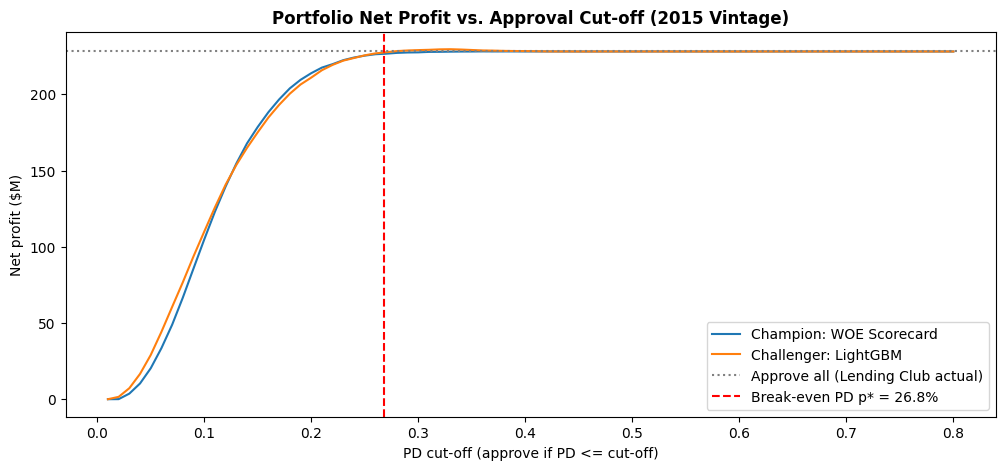

In [ ]:
print("--- Simulating Portfolio Financial Impact (2015 Vintage, Realized Cash Flows) ---")

# 1. Realized cash flows of each test loan
r = test['int_rate'].values / 1200                                   # monthly interest rate
A = test['installment'].values
L = test['funded_amnt'].values
is_bad = test['TARGET'].values == 1
months_paid = np.where(is_bad, test['mob_exit'] - 4, test['mob_exit']).clip(0, 36).astype(float)
balance_k = L * (1 + r) ** months_paid - A * ((1 + r) ** months_paid - 1) / r
interest_earned = months_paid * A - (L - balance_k)

lgd = test['grade'].map(lgd_sat['lra_by_grade']).fillna(lgd_sat['lra_default_weighted']).values
credit_loss = np.where(is_bad, test['ead'].values * lgd, 0.0)
test['PROFIT'] = interest_earned - credit_loss

G = test.loc[~is_bad, 'PROFIT'].mean()          # average profit of a good loan
C = -test.loc[is_bad, 'PROFIT'].mean()          # average net cost of a defaulted loan
p_star = G / (G + C)
print(f"Average profit per good loan:        ${G:,.0f}")
print(f"Average net loss per defaulted loan: ${C:,.0f}")
print(f"Break-even PD  p* = G / (G + C):      {p_star:.2%}\n")

# 2. Grid search over cut-offs for both models
thresholds = np.round(np.arange(0.01, 0.801, 0.01), 2)
sims = {}
for name, p in {'Champion: WOE Scorecard': lr_preds, 'Challenger: LightGBM': lgb_preds}.items():
    rows = []
    for t in thresholds:
        approve = p <= t
        rows.append({'Threshold': t, 'Approval Rate': approve.mean(),
                     'Approved Goods': int((approve & ~is_bad).sum()), 'Approved Defaults': int((approve & is_bad).sum()),
                     'Default Rate (Approved)': is_bad[approve].mean() if approve.any() else np.nan,
                     'Net Profit ($M)': test.loc[approve, 'PROFIT'].sum() / 1e6})
    sims[name] = pd.DataFrame(rows)

# 3. Results vs. Lending Club's actual policy (approve everyone in the test sample)
approve_all = test['PROFIT'].sum() / 1e6
summary = []
for name, sim in sims.items():
    best = sim.loc[sim['Net Profit ($M)'].idxmax()]
    summary.append({'Model': name, 'Optimal Threshold': best['Threshold'], 'Approval Rate': best['Approval Rate'],
                    'Default Rate (Approved)': best['Default Rate (Approved)'], 'Net Profit ($M)': best['Net Profit ($M)'],
                    'Gain vs. Approve-All ($M)': best['Net Profit ($M)'] - approve_all})
summary_df = pd.DataFrame(summary).set_index('Model')
print(f"Approve-all policy (Lending Club actual): ${approve_all:,.1f}M net profit on {len(test):,} loans "
      f"(default rate {is_bad.mean():.2%})")
print("\n--- Optimal Operating Points ---")
display(summary_df.round(4))

champ = sims['Champion: WOE Scorecard']
opt = champ['Net Profit ($M)'].idxmax()
print("\n--- Champion: Threshold Scenarios Around the Optimum ---")
display(champ.iloc[max(0, opt - 3): opt + 4].round(4))

# 4. Profit curves
fig, ax = plt.subplots(figsize=(12, 5))
for name, sim in sims.items():
    ax.plot(sim['Threshold'], sim['Net Profit ($M)'], label=name)
ax.axhline(approve_all, color='grey', ls=':', label='Approve all (Lending Club actual)')
ax.axvline(p_star, color='red', ls='--', label=f'Break-even PD p* = {p_star:.1%}')
ax.set_xlabel('PD cut-off (approve if PD <= cut-off)'); ax.set_ylabel('Net profit ($M)')
ax.set_title('Portfolio Net Profit vs. Approval Cut-off (2015 Vintage)', fontweight='bold'); ax.legend()
plt.show()

## Conclusion:
1. **Break-even PD.** A good loan earned **$1,811** of interest on average, and a defaulted loan cost **$4,942** net of the interest collected before default. The break-even PD is therefore **p* = 26.8%**, much higher than the 16.7% of the Home Credit version. Real Lending Club loans carried interest rates that rose steeply with risk, and the 91% LGD applies only to the balance still outstanding at default, which is much less than the original loan amount.

2. **The profit curve is flat above p*.** Net profit rises steeply up to a cut-off of about 25% and is essentially flat beyond 27%. The optimum sits **inside the grid**, just above p*:

| Policy | Cut-off | Approval Rate | Default Rate (Approved) | Net Profit | Gain |
|---|---|---|---|---|---|
| Approve all (Lending Club actual) | – | 100% | 14.9% | $228.1M | – |
| WOE scorecard | 36% | 99.9% | 14.9% | $228.2M | +$0.06M |
| LightGBM | 33% | 99.0% | 14.7% | $229.6M | **+$1.5M (+0.7%)** |

   Beyond p*, the curve is almost flat, because only about 1% of loans have PDs in that range. The exact location of the optimum (33% vs. 36%) is therefore statistical noise. The meaningful result is that nothing is gained by cutting deeper than about 27%.

3. **Why re-screening adds so little.** Lending Club had already rejected high-risk applicants and **priced** the rest by grade. Almost no approved borrower has a PD above the break-even level. The market was efficient at this margin: risk-based pricing had already done the work of the cut-off. A PD model creates value in three places:
   * **at the application stage**, where the riskiest applicants appear. Our data has no rejected applications, so this value cannot be measured here (reject inference);
   * **in pricing**, by setting the interest rate so that each loan clears its own break-even PD;
   * **in higher-cost environments.** Adding funding and servicing costs would lower G, reduce p* and make the cut-off bite much harder.

# Executive Summary

This project built a complete PD framework on **612,745 Lending Club loans**: an interpretable WOE scorecard (champion) and a LightGBM challenger. Both were trained on the 2010–2014 vintages, validated out of time on the **2015 vintage (283,026 loans, 14.9% default rate)** and translated into profit decisions using real cash flows and the LGD from Part 3.

## Model Performance (Out-of-Time: 2015 Vintage)

| Model | ROC-AUC | Gini | KS | Mean PD / Actual | Brier |
| --- | --- | --- | --- | --- | --- |
| Champion: WOE Scorecard (9 variables) | 0.649 | 0.298 | 21.3 | 0.88 | 0.1227 |
| Challenger: LightGBM | **0.672** | **0.344** | **25.0** | **0.91** | **0.1210** |

## Portfolio Optimization

| Policy | Cut-off | Approval Rate | Default Rate (Approved) | Net Profit ($M) |
| --- | --- | --- | --- | --- |
| Approve all (Lending Club actual) | – | 100% | 14.9% | 228.1 |
| Champion scorecard | 36% | 99.9% | 14.9% | 228.2 |
| LightGBM challenger | 33% | 99.0% | 14.7% | 229.6 |

> **Key Takeaway:** LightGBM ranks borrowers clearly better than the scorecard (+0.023 AUC, +3.7 KS). But because Lending Club had already screened and risk-priced its loans, the break-even PD (26.8%) lies above almost every approved borrower's PD, and re-screening adds only $1.5M (+0.7%). Both models are well-ranked but **under-calibrated by about 10%** on the riskier 2015 vintage, which calls for an intercept recalibration before any pricing use.

---

## Improvements over the Home Credit Version

1. **Out-of-time validation** on the 2015 vintage replaces the random 70/30 split. It revealed a 10% calibration shift that a random split would have hidden.
2. **WOE bins fitted on the training set only** (no leakage). All 9 scorecard coefficients have the correct sign.
3. **No class weights:** the PDs stay on the probability scale, which made the break-even check possible.
4. **The profit grid spans 1–80%**, and the optimum (33–36%) lies inside it, on the flat part of the curve above the analytical break-even PD (26.8%). The old boundary problem (an "optimum" at the 0.50 grid edge) is gone.
5. **Real interest rates, repayment timing and exposures** replace the assumed $15,000 at 12%, and the **91% LGD from Part 3** replaces the assumed 60%.
6. **No age or gender** in the model, and geography is excluded.

## Limitations

1. **Reject inference.** Only approved loans are observed. The model's true value, screening the full applicant pool, cannot be measured with this data.
2. **Funding and operating costs are ignored.** Including them would lower the break-even PD and increase the value of the model.
3. **Calibration drift.** The 2015 vintage was riskier than 2010–2014, and the PDs should be recalibrated to the latest default experience before use in pricing or expected-loss calculations.